# Credit Score Prediction Model

Synthetic dataset + ML pipeline + evaluation + visualization

## 1. Import Libraries

In [9]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import seaborn as sns
import matplotlib.pyplot as plt


## 2. Create Synthetic Dataset

In [10]:

np.random.seed(42)
n = 1000

data = pd.DataFrame({
    "income": np.random.randint(20000, 150000, n),
    "debt": np.random.randint(0, 50000, n),
    "payment_history": np.random.randint(0, 2, n),
    "credit_utilization": np.random.uniform(0, 1, n),
    "num_credit_cards": np.random.randint(1, 10, n)
})

data["creditworthy"] = (
    (data["income"] > 50000) &
    (data["debt"] < 20000) &
    (data["payment_history"] == 1) &
    (data["credit_utilization"] < 0.5)
).astype(int)

data.head()


,income,debt,payment_history,credit_utilization,num_credit_cards,creditworthy
0,141958,13216,0,0.627950,6,0
1,35795,35547,1,0.674304,5,0
2,20860,31471,0,0.532481,8,0
3,123694,17308,0,0.721422,6,0
4,148106,27532,0,0.141278,6,0


## 3. Train-Test Split

In [11]:

X = data.drop("creditworthy", axis=1)
y = data["creditworthy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 4. Build Pipelines

In [12]:

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])


## 5. Train Models

In [13]:

pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


## 6. Predictions

In [14]:

y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]


## 7. Evaluation

In [15]:

print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       178
           1       0.78      0.82      0.80        22

    accuracy                           0.95       200
   macro avg       0.88      0.90      0.89       200
weighted avg       0.96      0.95      0.96       200

ROC-AUC: 0.9790602655771196

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       178
           1       1.00      0.95      0.98        22

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200

ROC-AUC: 1.0


## 8. Visualization

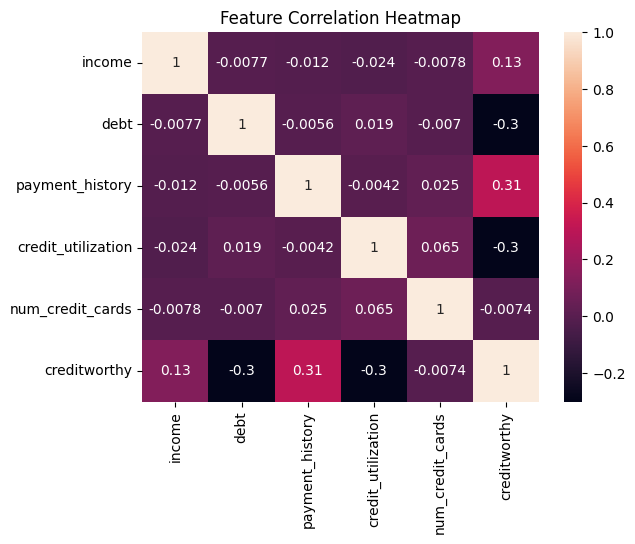

In [16]:

plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()
